Sucesso! Imagem 'inconsistencia_precos.png' gerada.


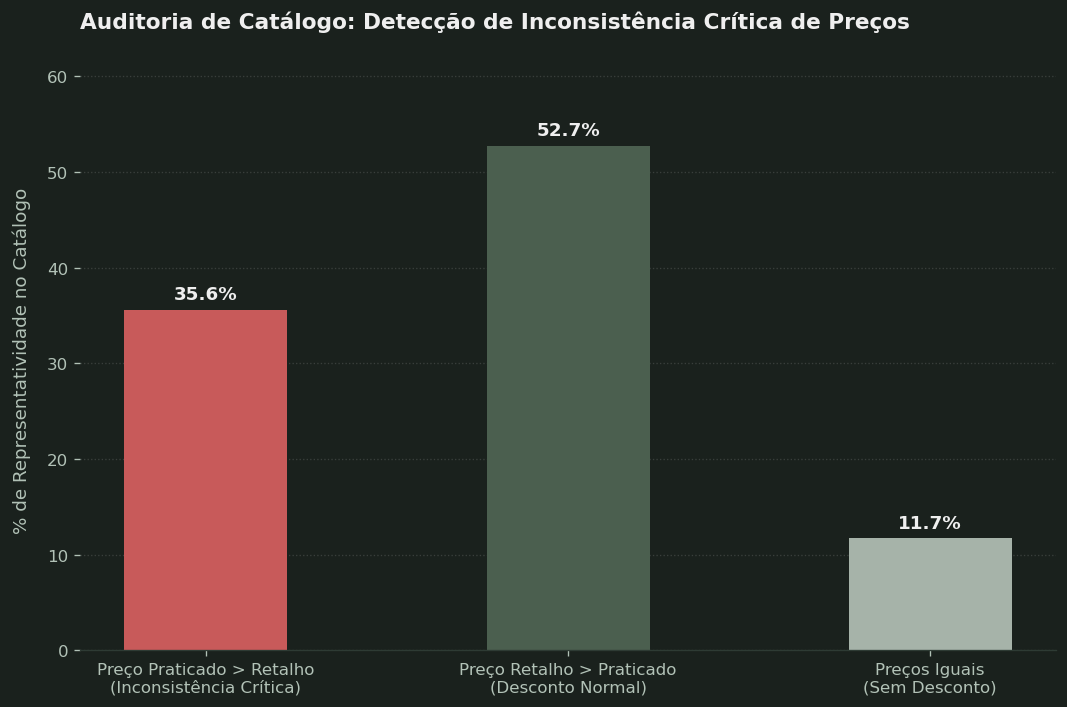

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregamento e tratamento dos dados
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    df = limpos[list(limpos.keys())[0]]
except Exception as e:
    print(f"Erro ao carregar o ficheiro: {e}")
    exit()

df['price_num'] = pd.to_numeric(df['price'], errors='coerce')
df['retail_num'] = pd.to_numeric(df['retail_price'], errors='coerce')
df_validos = df[(df['price_num'] > 0) & (df['retail_num'] > 0)].copy()

# Calcular percentuais de retail_price_DifFix
contagem_precos = df_validos['retail_price_DifFix'].value_counts()
total_precos = contagem_precos.sum()

pct_price_maior = (contagem_precos.get('price_maior', 0) / total_precos) * 100
pct_retail_maior = (contagem_precos.get('retail_maior', 0) / total_precos) * 100
pct_iguais = (contagem_precos.get('iguais', 0) / total_precos) * 100

# 2. Construção do Gráfico Isolado
cor_fundo = '#1A211D'
fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
fig.patch.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

cenarios = [
    'Preço Praticado > Retalho\n(Inconsistência Crítica)', 
    'Preço Retalho > Praticado\n(Desconto Normal)', 
    'Preços Iguais\n(Sem Desconto)'
]
valores_pct = [pct_price_maior, pct_retail_maior, pct_iguais]
cores = ['#C85A5A', '#4B5F4F', '#A6B3A9'] # Vermelho destaca o erro crítico

barras = ax.bar(cenarios, valores_pct, color=cores, width=0.45)

# Rótulos de dados no topo das barras
for bar in barras:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', color='#EFEFEF', fontsize=11, weight='bold')

# Estilização Executiva
ax.set_title('Auditoria de Catálogo: Detecção de Inconsistência Crítica de Preços', color='#EFEFEF', fontsize=13, pad=25, weight='bold', loc='left')
ax.set_ylabel('% de Representatividade no Catálogo', color='#B2C2B7', fontsize=11, labelpad=10)
ax.tick_params(colors='#B2C2B7', labelsize=10)
ax.set_ylim(0, max(valores_pct) * 1.15)
ax.grid(axis='y', linestyle=':', alpha=0.15, color='#EFEFEF')
ax.set_axisbelow(True)

# Remover bordas desnecessárias
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#2E3B34')

plt.tight_layout()
plt.savefig('inconsistencia_precos.png', facecolor=cor_fundo)
print("Sucesso! Imagem 'inconsistencia_precos.png' gerada.")
plt.show()


Gráfico de duas colunas gerado com sucesso como 'auditoria_urgencia_duas_colunas.png'!


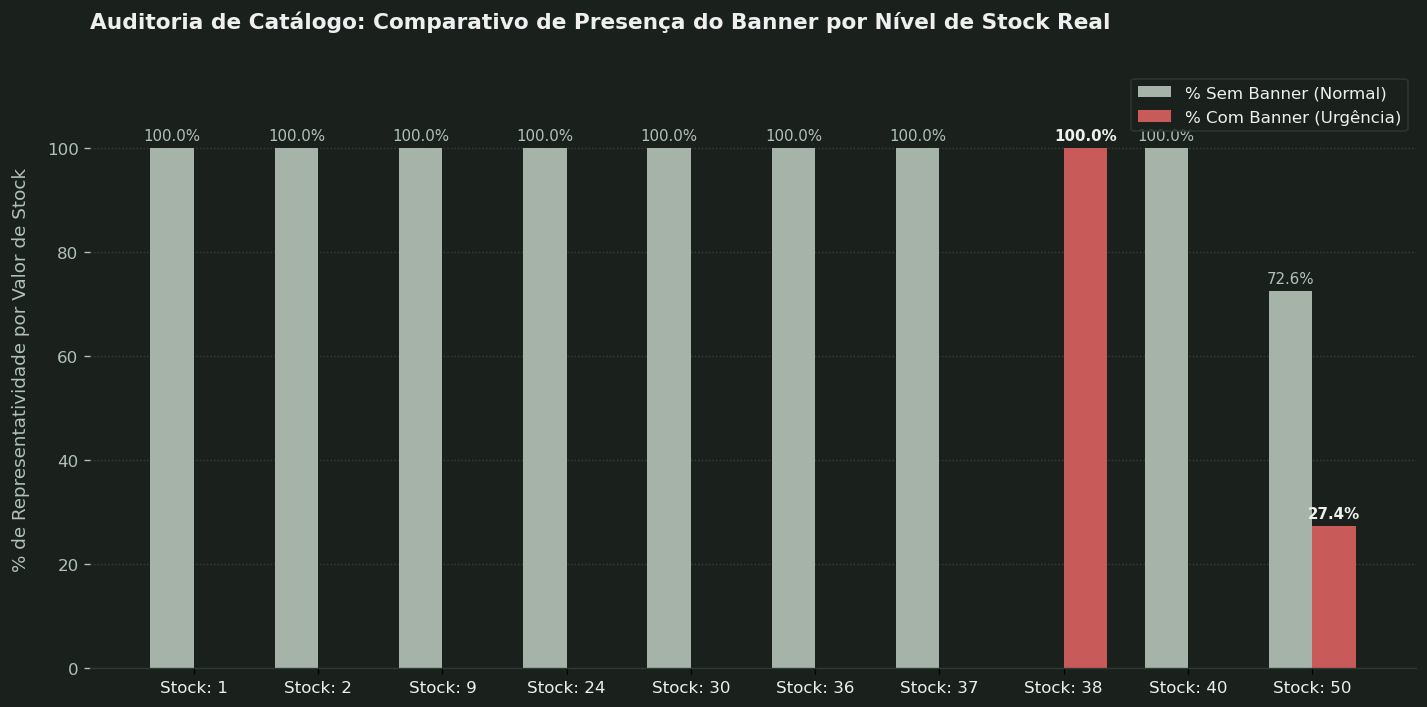

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregamento dos dados diretos do teu ficheiro Excel
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    df = limpos[list(limpos.keys())[0]]
except Exception as e:
    print(f"Erro ao carregar o ficheiro: {e}")
    exit()

# Garantir conversão numérica e booleana correta
df['inventory_total'] = pd.to_numeric(df['inventory_total'], errors='coerce')
df['has_urgency_bannerFix'] = df['has_urgency_bannerFix'].apply(lambda x: 1 if str(x).strip() in ['1', 'True', '1.0'] else 0)

# Remover registos com stock nulo ou inválido
df_validos = df[df['inventory_total'].notna()].copy()

# 2. Agrupamento por Valores Únicos de Stock
analise_valores_unicos = df_validos.groupby('inventory_total').agg(
    total_produtos=('product_id', 'count'),
    com_banner=('has_urgency_bannerFix', 'sum')
).reset_index()

# Calcular as duas percentagens (Com e Sem Banner)
analise_valores_unicos['pct_com_banner'] = (analise_valores_unicos['com_banner'] / analise_valores_unicos['total_produtos']) * 100
analise_valores_unicos['pct_sem_banner'] = 100 - analise_valores_unicos['pct_com_banner']

# Ordenar do menor stock para o maior
analise_valores_unicos = analise_valores_unicos.sort_values(by='inventory_total').reset_index(drop=True)

# 3. Construção do Gráfico de Barras Agrupadas (Duas Colunas)
cor_fundo = '#1A211D'
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
fig.patch.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

# Configuração das posições no eixo X
x_labels = [f"Stock: {int(val)}" for val in analise_valores_unicos['inventory_total']]
valores_com = analise_valores_unicos['pct_com_banner'].tolist()
valores_sem = analise_valores_unicos['pct_sem_banner'].tolist()

x_pos = np.arange(len(x_labels))
largura_barra = 0.35

# Plotagem das duas colunas lado a lado
barras_sem = ax.bar(x_pos - largura_barra/2, valores_sem, largura_barra, label='% Sem Banner (Normal)', color='#A6B3A9')
barras_com = ax.bar(x_pos + largura_barra/2, valores_com, largura_barra, label='% Com Banner (Urgência)', color='#C85A5A')

# Adicionar rótulos de dados no topo de todas as barras
for bar in barras_sem:
    height = bar.get_height()
    if height > 0.0:  # Só mostra se for maior que zero
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color='#B2C2B7', fontsize=9)

for bar in barras_com:
    height = bar.get_height()
    if height > 0.0:
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color='#EFEFEF', fontsize=9, weight='bold')

# Customização Executiva do Layout
ax.set_title('Auditoria de Catálogo: Comparativo de Presença do Banner por Nível de Stock Real', color='#EFEFEF', fontsize=13, pad=25, weight='bold', loc='left')
ax.set_ylabel('% de Representatividade por Valor de Stock', color='#B2C2B7', fontsize=11, labelpad=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, color='#EFEFEF', fontsize=10)
ax.tick_params(axis='y', colors='#B2C2B7', labelsize=10)

ax.set_ylim(0, 115) # Espaço para os rótulos não cortarem no topo
ax.grid(axis='y', linestyle=':', alpha=0.15, color='#EFEFEF')
ax.set_axisbelow(True)

# Legenda do Gráfico
ax.legend(facecolor=cor_fundo, edgecolor='#2E3B34', labelcolor='#EFEFEF', loc='upper right')

# Remover linhas de contorno desnecessárias
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#2E3B34')

plt.tight_layout()
plt.savefig('auditoria_urgencia_duas_colunas.png', facecolor=cor_fundo)
print("\nGráfico de duas colunas gerado com sucesso como 'auditoria_urgencia_duas_colunas.png'!")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>